# Kia EU Ownership Experience — Warranty KPI Dashboard
## Phase 3: Data Cleaning & Visualization
**Libraries:** Pandas, Matplotlib, Seaborn  
**Dataset:** vehicle_maintenance_data.csv  
**Teams covered:** Warranty | Service Marketing | BI

---
## Part A — Data Cleaning with Pandas

In [1]:
# ── Import libraries ──────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
# ── Load the CSV ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv('/Users/tharuntejamuthyala/Downloads/vehicle_maintenance_data.csv')

print(f'Raw shape: {df_raw.shape}')
df_raw.head()

Raw shape: (50000, 20)


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


In [3]:
# ── Keep only our 13 relevant columns ────────────────────────────────────────
cols_to_keep = [
    'Vehicle_Model',
    'Mileage',
    'Maintenance_History',
    'Reported_Issues',
    'Vehicle_Age',
    'Fuel_Type',
    'Odometer_Reading',
    'Last_Service_Date',
    'Warranty_Expiry_Date',
    'Owner_Type',
    'Accident_History',
    'Fuel_Efficiency',
    'Need_Maintenance'
]

df = df_raw[cols_to_keep].copy()
print(f'Shape after column selection: {df.shape}')
df.head()

Shape after column selection: (50000, 13)


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Accident_History,Fuel_Efficiency,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,28524,2023-11-23,2025-06-24,Second,3,13.622204,1
1,Van,60353,Average,1,7,Electric,133630,2023-09-21,2025-06-04,Second,0,13.625307,1
2,Bus,68072,Poor,0,2,Electric,34022,2023-06-27,2025-04-27,First,0,14.306302,1
3,Bus,60849,Average,4,5,Petrol,81636,2023-08-24,2025-11-05,Second,3,18.709467,1
4,Bus,45742,Poor,5,1,Petrol,97162,2023-05-25,2025-09-14,Third,2,16.977482,1


In [4]:
# ── Check data types and nulls ────────────────────────────────────────────────
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Null Counts ---')
print(df.isnull().sum())

--- Data Types ---
Vehicle_Model            object
Mileage                   int64
Maintenance_History      object
Reported_Issues           int64
Vehicle_Age               int64
Fuel_Type                object
Odometer_Reading          int64
Last_Service_Date        object
Warranty_Expiry_Date     object
Owner_Type               object
Accident_History          int64
Fuel_Efficiency         float64
Need_Maintenance          int64
dtype: object

--- Null Counts ---
Vehicle_Model           0
Mileage                 0
Maintenance_History     0
Reported_Issues         0
Vehicle_Age             0
Fuel_Type               0
Odometer_Reading        0
Last_Service_Date       0
Warranty_Expiry_Date    0
Owner_Type              0
Accident_History        0
Fuel_Efficiency         0
Need_Maintenance        0
dtype: int64


In [17]:
# Fix date columns 
df['Last_Service_Date']    = pd.to_datetime(df['Last_Service_Date'],    errors='coerce')
df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'], errors='coerce')

print('✅ Date columns fixed')
print(df[['Last_Service_Date', 'Warranty_Expiry_Date']].dtypes)

✅ Date columns fixed
Last_Service_Date       datetime64[ns]
Warranty_Expiry_Date    datetime64[ns]
dtype: object


In [6]:
# ── Fix numeric columns ───────────────────────────────────────────────────────
num_cols = ['Mileage', 'Reported_Issues', 'Vehicle_Age',
            'Odometer_Reading', 'Accident_History', 'Fuel_Efficiency']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Need_Maintenance'] = df['Need_Maintenance'].astype(int)

print('✅ Numeric columns fixed')

✅ Numeric columns fixed


In [7]:
# ── Normalize text columns ────────────────────────────────────────────────────
text_cols = ['Vehicle_Model', 'Maintenance_History',
             'Fuel_Type', 'Owner_Type']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()
#strip()-removes psaces before & afer
print('✅ Text columns normalized')
print('\nVehicle Models:', df['Vehicle_Model'].unique())
print('Fuel Types:',      df['Fuel_Type'].unique())
print('Owner Types:',     df['Owner_Type'].unique())
print('Maintenance:',     df['Maintenance_History'].unique())

✅ Text columns normalized

Vehicle Models: ['Truck' 'Van' 'Bus' 'Motorcycle' 'Suv' 'Car']
Fuel Types: ['Electric' 'Petrol' 'Diesel']
Owner Types: ['Second' 'First' 'Third']
Maintenance: ['Good' 'Average' 'Poor']


In [8]:
# ── Handle nulls ──────────────────────────────────────────────────────────────
# Fill numeric nulls with median
for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

print('✅ Nulls handled')
print('\nNull counts after cleaning:')
print(df.isnull().sum())

✅ Nulls handled

Null counts after cleaning:
Vehicle_Model           0
Mileage                 0
Maintenance_History     0
Reported_Issues         0
Vehicle_Age             0
Fuel_Type               0
Odometer_Reading        0
Last_Service_Date       0
Warranty_Expiry_Date    0
Owner_Type              0
Accident_History        0
Fuel_Efficiency         0
Need_Maintenance        0
dtype: int64


In [19]:
# ── Engineer new features ─────────────────────────────────────────────────────
import datetime
today = pd.Timestamp.today()

# 1. Warranty status — Active or Expired
df['Warranty_Status'] = df['Warranty_Expiry_Date'].apply(
    lambda x: 'Active' if pd.notna(x) and x >= today else 'Expired'
)

# 2. Days until warranty expires (negative = already expired)
df['Days_To_Expiry'] = (df['Warranty_Expiry_Date'] - today).dt.days

# 3. Vehicle age Group
df['Age_Group'] = pd.cut(
    df['Vehicle_Age'],
    bins    = [0, 1, 2, 3, 5, 8, 100],
    labels  = ['Under 1 yr', '1-2 yrs', '2-3 yrs', '3-5 yrs', '5-8 yrs', 'Over 8 yrs']
)

# 4. Service month (for trend chart)
df['Service_Month'] = df['Last_Service_Date'].dt.to_period('M').astype(str)

print('✅ New features created')
print('\nWarranty Status breakdown:')
print(df['Warranty_Status'].value_counts())
print('\nAge Group breakdown:')
print(df['Age_Group'].value_counts().sort_index())

✅ New features created

Warranty Status breakdown:
Warranty_Status
Expired    49410
Active       590
Name: count, dtype: int64

Age Group breakdown:
Age_Group
Under 1 yr     5046
1-2 yrs        4958
2-3 yrs        5039
3-5 yrs       10126
5-8 yrs       14779
Over 8 yrs    10052
Name: count, dtype: int64


In [20]:
# ── Export clean dataset ──────────────────────────────────────────────────────
import os
os.makedirs('outputs', exist_ok=True)

df.to_csv('outputs/warranty_clean.csv', index=False)

print(f'Clean dataset exported: {df.shape[0]} rows × {df.shape[1]} columns')
print('Saved to: outputs/warranty_clean.csv')
df.head()

Clean dataset exported: 50000 rows × 17 columns
Saved to: outputs/warranty_clean.csv


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Accident_History,Fuel_Efficiency,Need_Maintenance,Warranty_Status,Days_To_Expiry,Age_Group,Service_Month
0,Truck,58765,Good,0,4,Electric,28524,2023-11-23,2025-06-24,Second,3,13.622204,1,Expired,-271,3-5 yrs,2023-11
1,Van,60353,Average,1,7,Electric,133630,2023-09-21,2025-06-04,Second,0,13.625307,1,Expired,-291,5-8 yrs,2023-09
2,Bus,68072,Poor,0,2,Electric,34022,2023-06-27,2025-04-27,First,0,14.306302,1,Expired,-329,1-2 yrs,2023-06
3,Bus,60849,Average,4,5,Petrol,81636,2023-08-24,2025-11-05,Second,3,18.709467,1,Expired,-137,3-5 yrs,2023-08
4,Bus,45742,Poor,5,1,Petrol,97162,2023-05-25,2025-09-14,Third,2,16.977482,1,Expired,-189,Under 1 yr,2023-05


---
## Part B — Visualizations with Matplotlib & Seaborn

In [21]:
# ── Chart style setup ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']      = 120
plt.rcParams['figure.figsize']  = (10, 5)
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.titleweight']= 'bold'

KIA_COLORS = ['#05141F', '#BB162B', '#4A90D9', '#6C757D', '#28A745', '#FFC107']
print('✅ Chart style ready')

✅ Chart style ready


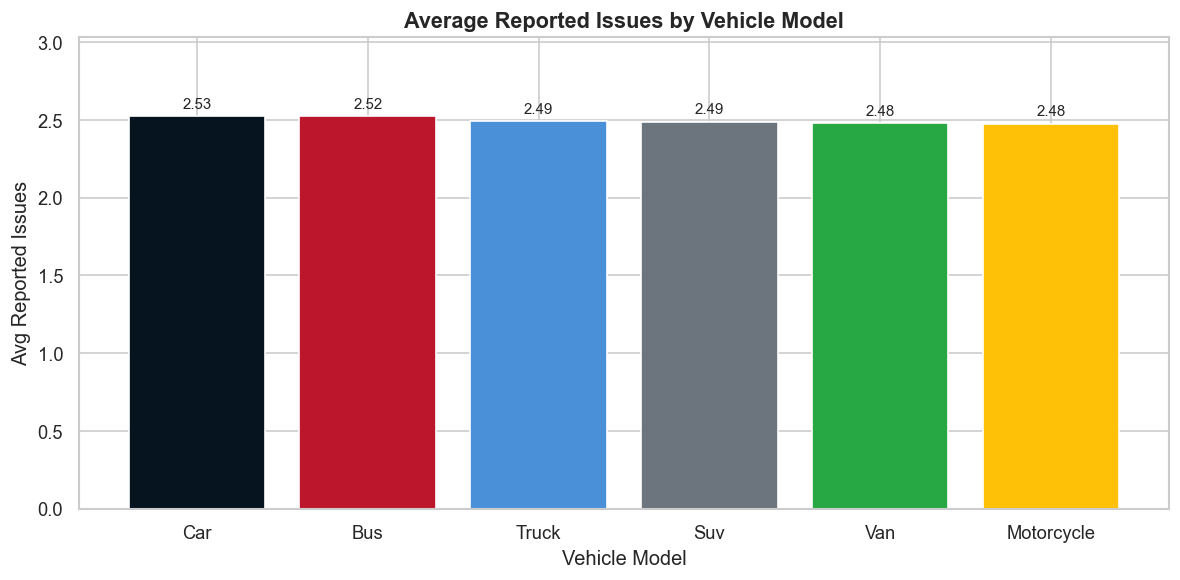

✅ Chart 1 saved


In [22]:
# ── Chart 1: Reported Issues by Vehicle Model (Warranty Team) ─────────────────
model_issues = (
    df.groupby('Vehicle_Model')['Reported_Issues']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots()
bars = ax.bar(
    model_issues['Vehicle_Model'],
    model_issues['Reported_Issues'],
    color=KIA_COLORS
)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('Average Reported Issues by Vehicle Model')
ax.set_xlabel('Vehicle Model')
ax.set_ylabel('Avg Reported Issues')
ax.set_ylim(0, model_issues['Reported_Issues'].max() * 1.2)
plt.tight_layout()
plt.savefig('outputs/chart1_issues_by_model.png', bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved')

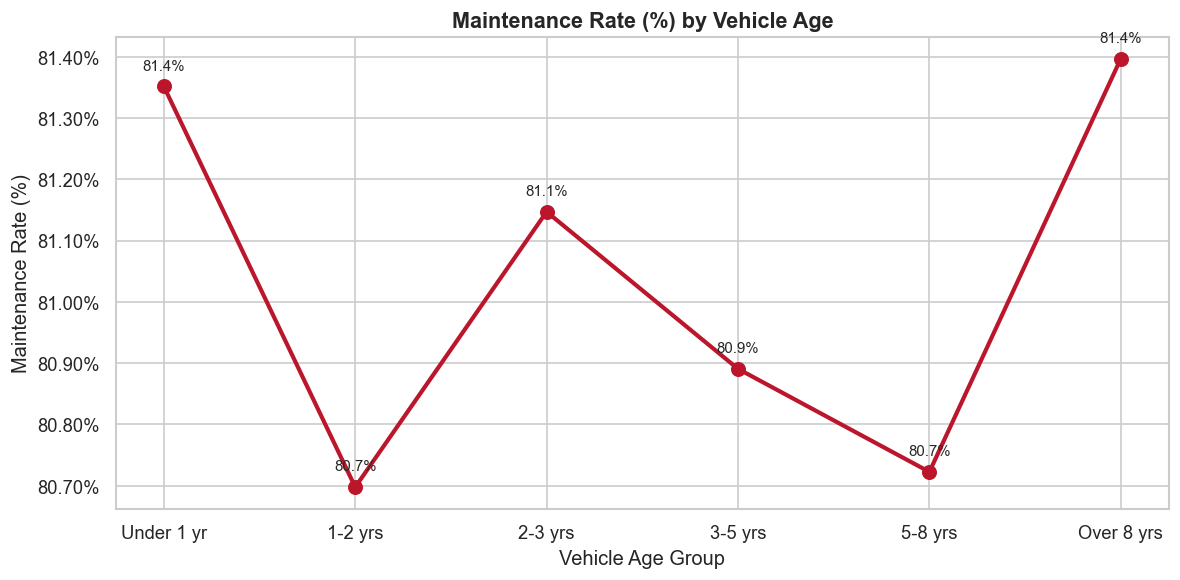

✅ Chart 2 saved


In [23]:
# ── Chart 2: Maintenance Rate by Vehicle Age Bucket (Warranty Team) ───────────
age_data = (
    df.groupby('Age_Group', observed=True)['Need_Maintenance']
    .mean()
    .mul(100)
    .reset_index()
)

fig, ax = plt.subplots()
ax.plot(
    age_data['Age_Group'].astype(str),
    age_data['Need_Maintenance'],
    marker='o', linewidth=2.5,
    color=KIA_COLORS[1], markersize=8
)
for i, row in age_data.iterrows():
    ax.annotate(f"{row['Need_Maintenance']:.1f}%",
                (str(row['Age_Group']), row['Need_Maintenance']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Maintenance Rate (%) by Vehicle Age')
ax.set_xlabel('Vehicle Age Group')
ax.set_ylabel('Maintenance Rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('outputs/chart2_maintenance_by_age.png', bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved')

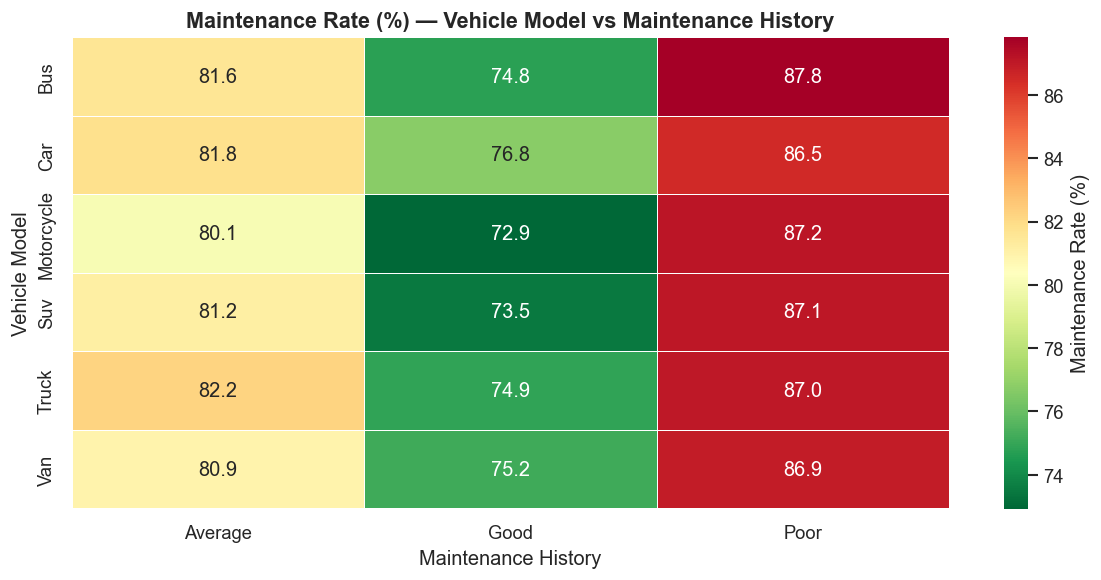

✅ Chart 3 saved


In [24]:
# ── Chart 3: Maintenance History Heatmap by Model (Warranty Team) ─────────────
heatmap_data = (
    df.groupby(['Vehicle_Model', 'Maintenance_History'])['Need_Maintenance']
    .mean()
    .mul(100)
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Maintenance Rate (%)'},
    ax=ax
)
ax.set_title('Maintenance Rate (%) — Vehicle Model vs Maintenance History')
ax.set_xlabel('Maintenance History')
ax.set_ylabel('Vehicle Model')
plt.tight_layout()
plt.savefig('outputs/chart3_heatmap_model_history.png', bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved')

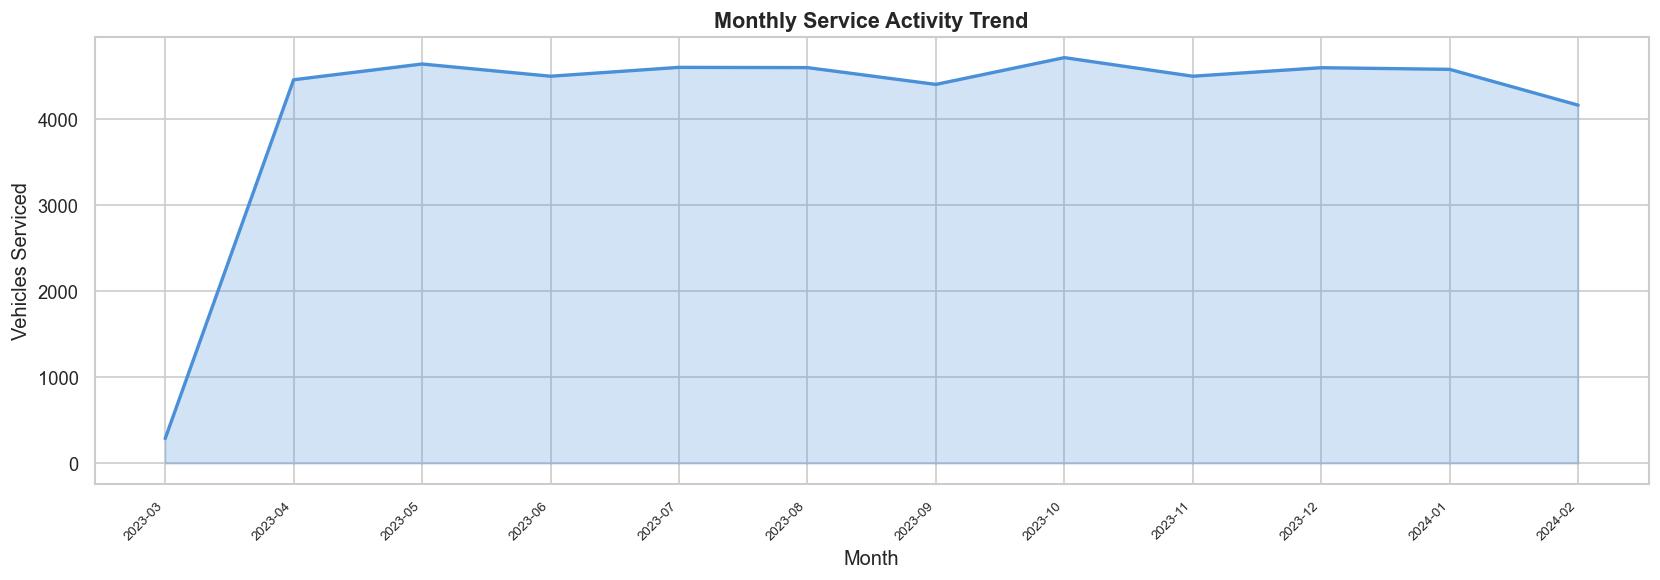

✅ Chart 4 saved


In [25]:
# ── Chart 4: Monthly Service Activity Trend (Service Marketing Team) ──────────
monthly = (
    df.groupby('Service_Month')
    .size()
    .reset_index(name='Vehicles_Serviced')
    .sort_values('Service_Month')
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly['Service_Month'],
                monthly['Vehicles_Serviced'],
                alpha=0.25, color=KIA_COLORS[2])
ax.plot(monthly['Service_Month'],
        monthly['Vehicles_Serviced'],
        color=KIA_COLORS[2], linewidth=2)
ax.set_title('Monthly Service Activity Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Vehicles Serviced')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/chart4_monthly_service_trend.png', bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved')

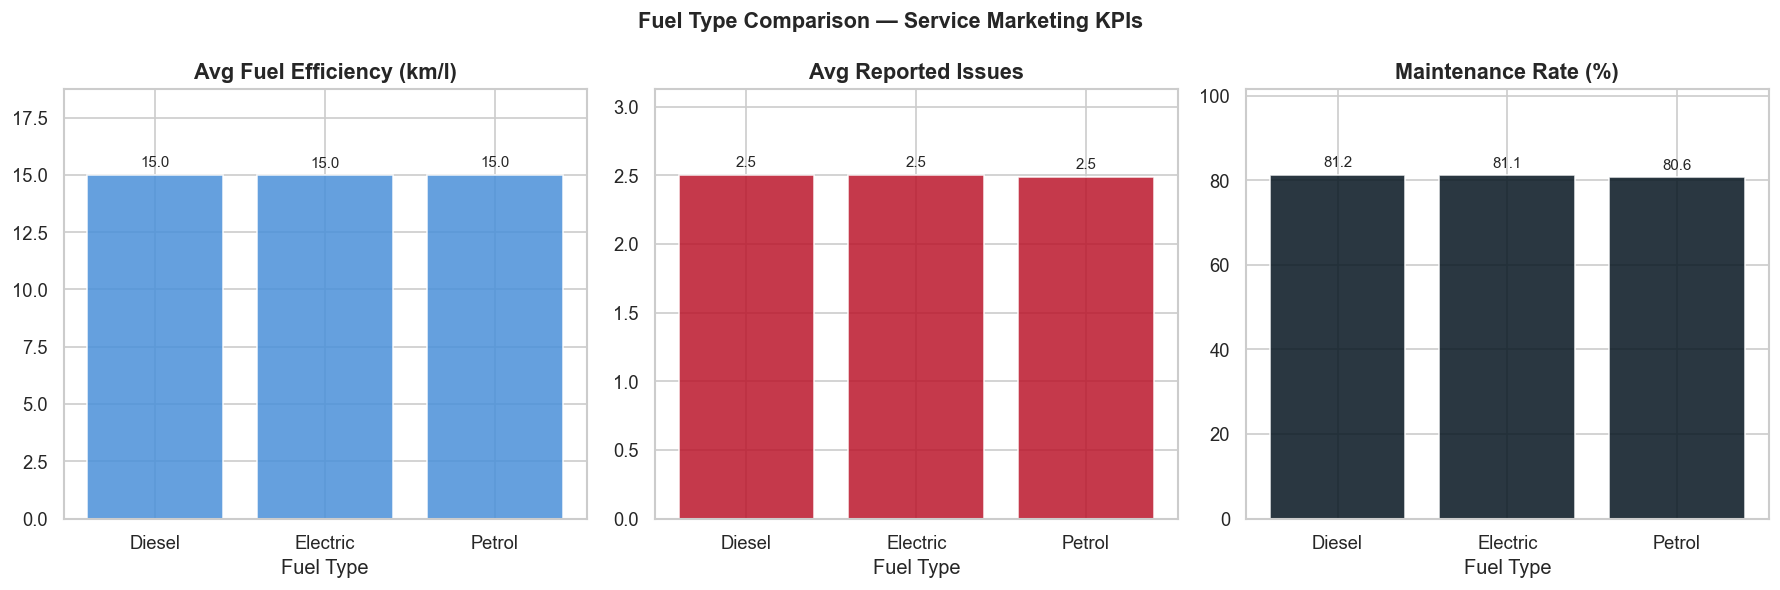

✅ Chart 5 saved


In [26]:
# ── Chart 5: Fuel Type Comparison (Service Marketing Team) ────────────────────
fuel_data = (
    df.groupby('Fuel_Type')
    .agg(
        Total_Vehicles   = ('Vehicle_Model',   'count'),
        Avg_Efficiency   = ('Fuel_Efficiency',  'mean'),
        Avg_Issues       = ('Reported_Issues',  'mean'),
        Maintenance_Rate = ('Need_Maintenance', 'mean')
    )
    .reset_index()
)
fuel_data['Maintenance_Rate'] = fuel_data['Maintenance_Rate'] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fuel Type Comparison — Service Marketing KPIs', fontsize=13, fontweight='bold')

metrics = [
    ('Avg_Efficiency',   'Avg Fuel Efficiency (km/l)', KIA_COLORS[2]),
    ('Avg_Issues',       'Avg Reported Issues',        KIA_COLORS[1]),
    ('Maintenance_Rate', 'Maintenance Rate (%)',        KIA_COLORS[0]),
]

for ax, (col, label, color) in zip(axes, metrics):
    bars = ax.bar(fuel_data['Fuel_Type'], fuel_data[col], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(label)
    ax.set_xlabel('Fuel Type')
    ax.set_ylim(0, fuel_data[col].max() * 1.25)

plt.tight_layout()
plt.savefig('outputs/chart5_fuel_type_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved')

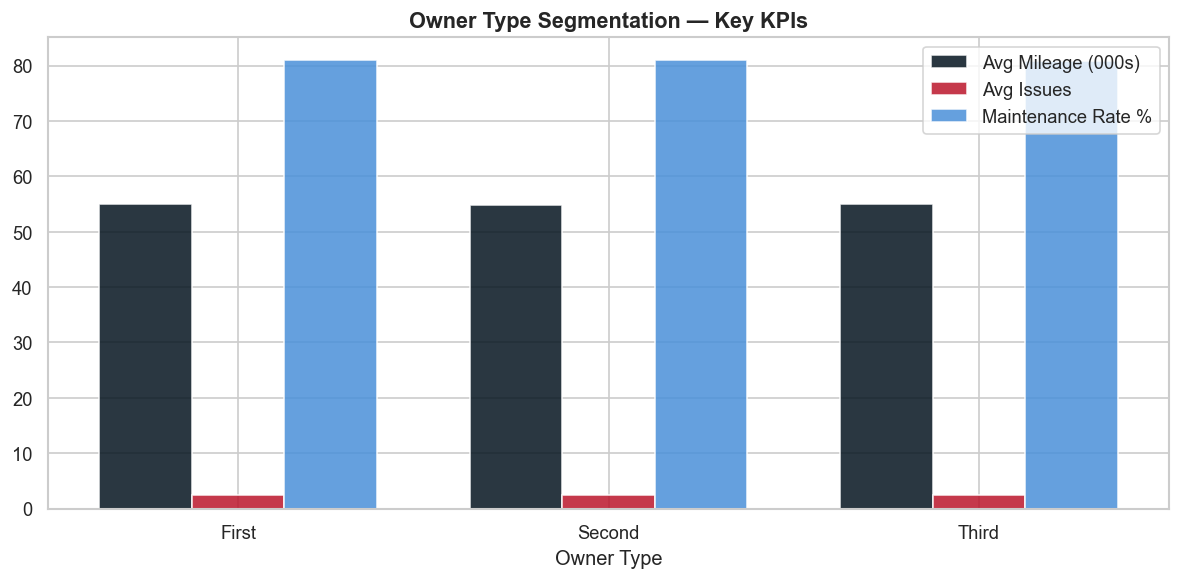

✅ Chart 6 saved


In [27]:
# ── Chart 6: Owner Type Segmentation (Service Marketing Team) ─────────────────
owner_data = (
    df.groupby('Owner_Type')
    .agg(
        Avg_Mileage      = ('Mileage',          'mean'),
        Avg_Issues       = ('Reported_Issues',  'mean'),
        Maintenance_Rate = ('Need_Maintenance', 'mean')
    )
    .reset_index()
)
owner_data['Maintenance_Rate'] = owner_data['Maintenance_Rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
x     = range(len(owner_data))
width = 0.25

b1 = ax.bar([i - width for i in x], owner_data['Avg_Mileage'] / 1000,
            width, label='Avg Mileage (000s)', color=KIA_COLORS[0], alpha=0.85)
b2 = ax.bar(x,                       owner_data['Avg_Issues'],
            width, label='Avg Issues',          color=KIA_COLORS[1], alpha=0.85)
b3 = ax.bar([i + width for i in x], owner_data['Maintenance_Rate'],
            width, label='Maintenance Rate %',  color=KIA_COLORS[2], alpha=0.85)

ax.set_title('Owner Type Segmentation — Key KPIs')
ax.set_xlabel('Owner Type')
ax.set_xticks(list(x))
ax.set_xticklabels(owner_data['Owner_Type'])
ax.legend()
plt.tight_layout()
plt.savefig('outputs/chart6_owner_type_segmentation.png', bbox_inches='tight')
plt.show()
print('✅ Chart 6 saved')

In [28]:
# ── Summary ───────────────────────────────────────────────────────────────────
print('============================================')
print(' Phase 3 Complete!')
print('============================================')
print(f' Clean dataset : outputs/warranty_clean.csv')
print(f' Charts saved  : outputs/chart1 to chart6')
print(f' Total rows    : {len(df):,}')
print(f' Total columns : {len(df.columns)}')
print('============================================')

 Phase 3 Complete!
 Clean dataset : outputs/warranty_clean.csv
 Charts saved  : outputs/chart1 to chart6
 Total rows    : 50,000
 Total columns : 17
